# EccoPy-1D Workflow

EccoPy-1D classifies a **single 1-D reflectivity profile** — one time
series, one range/distance transect, one ray — into Stratiform / Mixed /
Convective echo, using a sliding-window texture calculation.

This notebook is self-contained (synthetic data, no external files) and
walks through:

1. Generating a synthetic profile
2. `WindowSpec` — the texture window (physical vs. pixel, uniform vs. varying)
3. `TextureParams` — texture → convectivity mapping
4. `ClassificationParams` — convectivity → echo type thresholds
5. Debugging with `return_intermediates=True`
6. Statistics with `eccopy.stats`
7. Plotting with EccoPy's colormaps
8. A window-size sensitivity sweep


In [1]:
import sys
from pathlib import Path

# Walk up from the notebook's location until we find the directory
# containing the `eccopy` package folder, then add it to sys.path.
here = Path.cwd()
for candidate in [here, *here.parents]:
    if (candidate / "eccopy").is_dir():
        sys.path.insert(0, str(candidate))
        break

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.set_printoptions(precision=3, suppress=True)


In [2]:
from eccopy import eccopy1d, stats
from eccopy.params import WindowSpec, TextureParams, ClassificationParams
from eccopy.core.colormaps import (
    basic_echo_type_cmap, basic_echo_type_norm, BASIC_ECHO_TYPE_LABELS,
    convectivity_cmap, convectivity_norm,
)

## 1. Generate synthetic data

A 300-point profile along a 150 km transect: a gently varying stratiform
background, one embedded convective burst, and a short data gap (NaN) to
show EccoPy handles missing data.


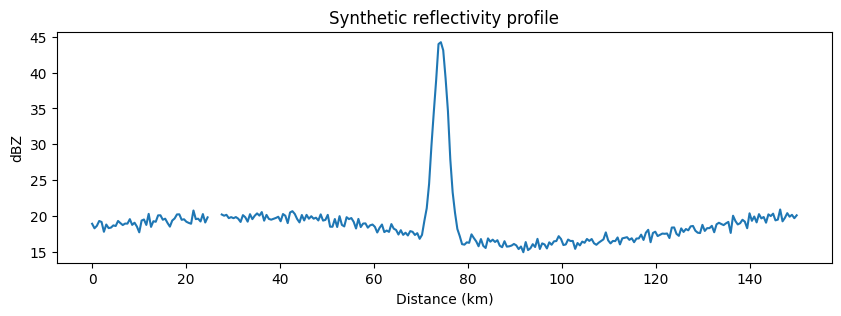

In [3]:
np.random.seed(0)
n = 300
coords = np.linspace(0, 150, n)                        # km, monotonic positions
dbz = 18 + 2 * np.sin(coords / 20) + np.random.normal(0, 0.5, n)
dbz[140:156] += 28 * np.exp(-0.5 * ((np.arange(-8, 8)) / 3) ** 2)  # embedded storm
dbz[50:55] = np.nan                                     # a data gap, for realism

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(coords, dbz)
ax.set(xlabel="Distance (km)", ylabel="dBZ", title="Synthetic reflectivity profile")
plt.show()

## 2. `WindowSpec` — the texture window

The texture statistic at each point is computed over a sliding window.
`WindowSpec` describes that window two ways:

- **Physical radius**: `WindowSpec((5, "km"))` — 5 km on either side,
  resolved to a pixel radius using your `coords` array. This is usually
  what you want for irregularly-sampled or coarse data.
- **Fixed pixel radius**: `WindowSpec(7)` — always 7 points on either
  side, regardless of physical spacing. Matches the ConvStratFinder
  constructor default (`window_1d=WindowSpec(19)`, i.e. a 19-pixel-wide
  window) if you don't specify anything.

`kernel_mode` controls how a *physical* WindowSpec is resolved when
spacing is non-uniform:
- `"uniform"` (default) — one representative (median) spacing is used
  for the whole profile, so every point gets the same pixel radius.
  Cheaper, and what's been validated against real MATLAB/C++ output.
- `"varying"` — each point resolves its own pixel radius from its local
  spacing. More physically correct for genuinely irregular sampling
  (e.g. a ray with dropped pulses), but unvalidated against a reference
  in this configuration.


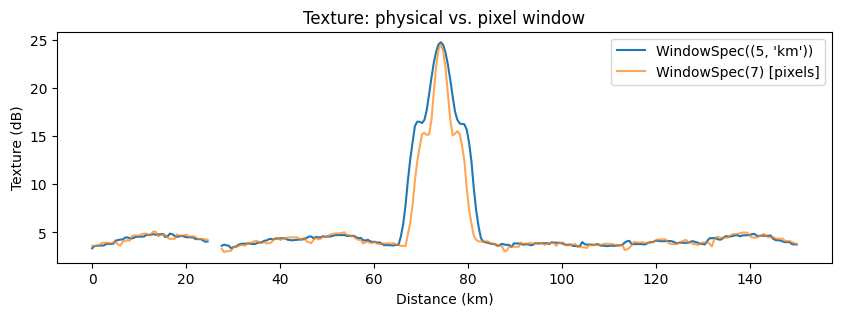

In [4]:
window_physical = WindowSpec((5, "km"))   # 5 km radius, resolved per-point
window_pixels = WindowSpec(7)             # fixed 7-pixel radius

r_physical = eccopy1d.run(dbz, coords=coords, window=window_physical)
r_pixels = eccopy1d.run(dbz, coords=coords, window=window_pixels)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(coords, r_physical.texture, label="WindowSpec((5, 'km'))")
ax.plot(coords, r_pixels.texture, label="WindowSpec(7) [pixels]", alpha=0.7)
ax.set(xlabel="Distance (km)", ylabel="Texture (dB)", title="Texture: physical vs. pixel window")
ax.legend()
plt.show()

## 3. `TextureParams` — texture → convectivity

Two fields matter for EccoPy-1D:

| Field | Meaning | Default |
|---|---|---|
| `upper_lim_dbz` | Texture value at/above which convectivity saturates to 1 (linear ramp from 0) | 29.0 |
| `dbz_base` | Subtracted from reflectivity before texture is computed | 0.0 |

Lowering `upper_lim_dbz` makes the algorithm reach "fully convective"
sooner — more of the profile gets pushed toward `convectivity=1` for the
same underlying texture.


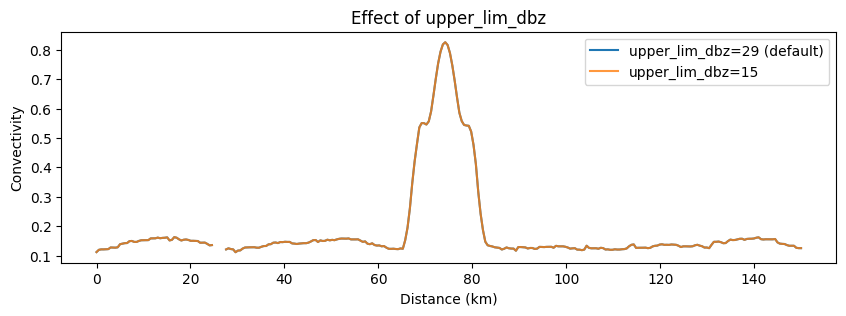

In [5]:
tp_default = TextureParams()                    # upper_lim_dbz=29.0
tp_sensitive = TextureParams(upper_lim_dbz=15.0)  # saturates sooner -> more convective-leaning

r_default = eccopy1d.run(dbz, coords=coords, window=window_physical, texture_params=tp_default)
r_sensitive = eccopy1d.run(dbz, coords=coords, window=window_physical, texture_params=tp_sensitive)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(coords, r_default.convectivity, label="upper_lim_dbz=29 (default)")
ax.plot(coords, r_sensitive.convectivity, label="upper_lim_dbz=15", alpha=0.8)
ax.set(xlabel="Distance (km)", ylabel="Convectivity", title="Effect of upper_lim_dbz")
ax.legend()
plt.show()

## 4. `ClassificationParams` — convectivity → echo type

Basic (1-D/2-D) classification thresholds:

| Field | Meaning | Default |
|---|---|---|
| `max_convectivity_for_stratiform` | Below this convectivity -> Stratiform | 0.4 |
| `min_convectivity_for_convective` | At/above this convectivity -> Convective | 0.5 |
| (between the two) | -> Mixed | — |
| `enlarge_mixed` | Dilation radius (pixels) applied to the Mixed mask during cleanup | 5 |
| `enlarge_conv` | Dilation radius (pixels) applied to the Convective mask during cleanup | 5 |
| `surf_alt_lim` | Minimum AGL (m) for a point to be classified at all | 200 |

`enlarge_mixed`/`enlarge_conv` are literal pixel counts, not physical
distances — see the `ClassificationParams` docstring for why (no
spacing array is consulted at this stage).

`min_convective_length` (an EccoPy-1D-specific, `run()`-level parameter,
not part of `ClassificationParams`) optionally drops any convective run
shorter than a given length, demoting it to Mixed. It defaults to `None`
(no filtering) since there's no validated default for arbitrary 1-D data.


In [6]:
cp_default = ClassificationParams()
cp_tighter = ClassificationParams(max_convectivity_for_stratiform=0.3,
                                  min_convectivity_for_convective=0.6)

r_default = eccopy1d.run(dbz, coords=coords, window=window_physical, class_params=cp_default)
r_tighter = eccopy1d.run(dbz, coords=coords, window=window_physical, class_params=cp_tighter)

print("Default thresholds  -- Strat/Mixed/Conv counts:",
      [int(np.sum(r_default.echo_type == c)) for c in (1, 2, 3)])
print("Tighter thresholds  -- Strat/Mixed/Conv counts:",
      [int(np.sum(r_tighter.echo_type == c)) for c in (1, 2, 3)])

# min_convective_length: drop short convective runs (e.g. isolated noise spikes)
r_filtered = eccopy1d.run(dbz, coords=coords, window=window_physical,
                          min_convective_length=WindowSpec((3, "km")))
print("With min_convective_length filter -- Conv count:",
      int(np.sum(r_filtered.echo_type == 3)))

Default thresholds  -- Strat/Mixed/Conv counts: [260, 4, 31]
Tighter thresholds  -- Strat/Mixed/Conv counts: [258, 18, 19]
With min_convective_length filter -- Conv count: 31


## 5. Debugging with `return_intermediates=True`

Pass `return_intermediates=True` to also get `fitted_dbz` and
`detrended_dbz` — the per-point local-linear-fit value and the
detrended/clipped value that actually feeds the texture statistic. This
costs a little extra compute (same Numba core, extra outputs) but no
extra passes over the data, and both fields are `None` by default.

Useful for answering "why did this point get the texture value it did?"
without stepping through `core.debug.refl_texture_1d_debug()` by hand.


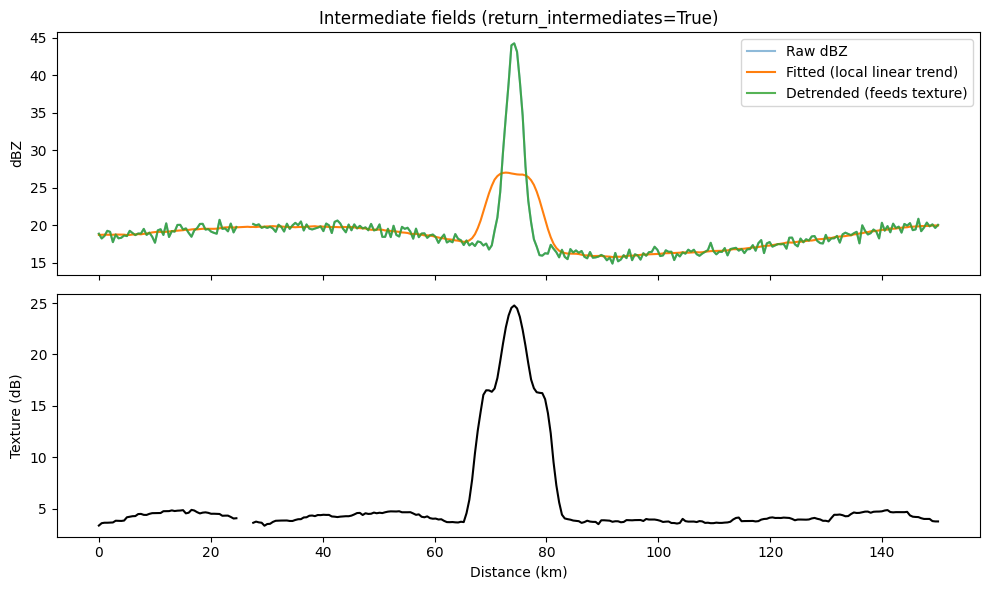

In [7]:
r_debug = eccopy1d.run(dbz, coords=coords, window=window_physical, return_intermediates=True)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(coords, dbz, label="Raw dBZ", alpha=0.5)
axes[0].plot(coords, r_debug.fitted_dbz, label="Fitted (local linear trend)")
axes[0].plot(coords, r_debug.detrended_dbz, label="Detrended (feeds texture)", alpha=0.8)
axes[0].set(ylabel="dBZ", title="Intermediate fields (return_intermediates=True)")
axes[0].legend()

axes[1].plot(coords, r_debug.texture, color="k")
axes[1].set(xlabel="Distance (km)", ylabel="Texture (dB)")
plt.tight_layout()
plt.show()

## 6. Statistics with `eccopy.stats`

`eccopy.stats` works on any module's `echo_type` output. For a 1-D
profile, the height/depth functions don't apply (no vertical axis), but
coverage fractions and clump counts do.


In [8]:
print("Convective percentage: %.1f%%" % stats.convective_percentage(r_debug.echo_type))
print("Stratiform percentage: %.1f%%" % stats.stratiform_percentage(r_debug.echo_type))
print("Number of convective clumps (runs):", stats.n_clumps(r_debug.echo_type, category="convective"))
print("Convective clump sizes (pixels):", stats.clump_sizes(r_debug.echo_type, category="convective"))
print()
print("summarize():")
for k, v in stats.summarize(r_debug.echo_type).items():
    print(f"  {k}: {v}")

Convective percentage: 10.5%
Stratiform percentage: 88.1%
Number of convective clumps (runs): 1
Convective clump sizes (pixels): [31.]

summarize():
  n_valid: 295
  stratiform: 0.8813559322033898
  mixed: 0.013559322033898305
  convective: 0.10508474576271186
  convective_pct: 10.508474576271187
  stratiform_pct: 88.13559322033899
  mixed_pct: 1.3559322033898304
  n_convective_clumps: 1
  n_stratiform_clumps: 3
  convective_clump_sizes: [31.]
  mean_convective_clump_size: 31.0


## 7. Plotting with EccoPy's colormaps

`eccopy.core.colormaps` provides a shared color language across all four
modules: `basic_echo_type_cmap()`/`norm()` for 1/2/3-code results (what
EccoPy-1D always produces), `echo_type_cmap()`/`norm()` for
sub-classified 9-code results (EccoPy-2D-V / 3D only), and
`convectivity_cmap()`/`norm()` for the convectivity field.

`convectivity_cmap()` ramps continuously *within* each class but has
**hard breaks** at the two classification thresholds — strat/mixed
(`params.strat_mixed`, default 0.4) and mixed/conv (`params.mixed_conv`,
default 0.5). So blue / teal / red on a convectivity panel correspond
directly to Stratiform / Mixed / Convective, while the shading within a
band still shows how marginal or how firmly-held that call is. If you
classify with non-default thresholds, pass them through so the breaks
follow: `convectivity_cmap(params.strat_mixed, params.mixed_conv)`.


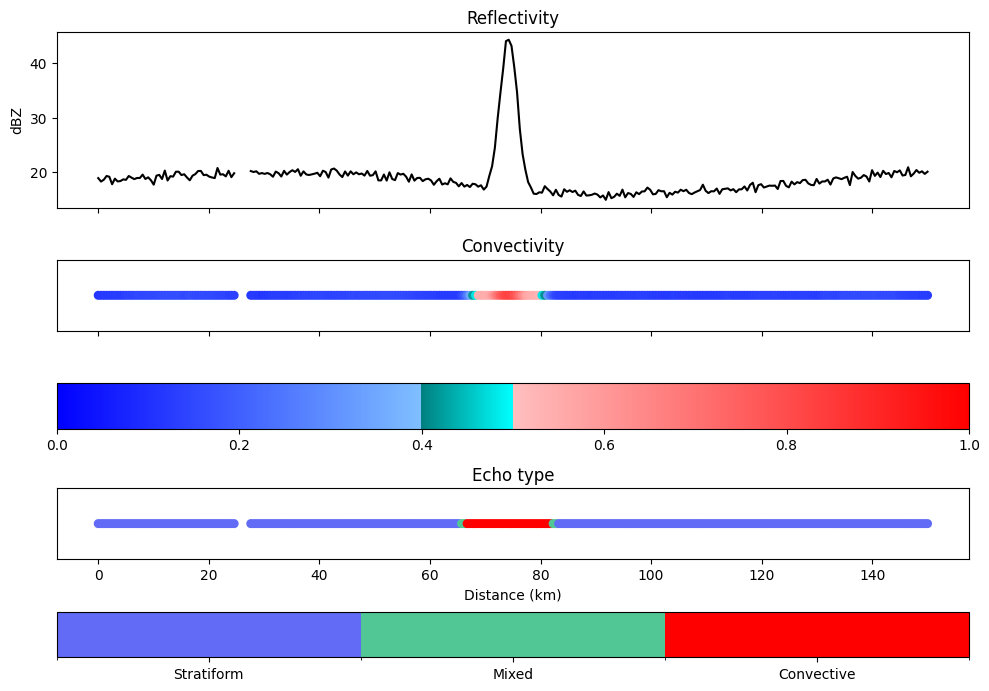

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

axes[0].plot(coords, dbz, color="k")
axes[0].set(ylabel="dBZ", title="Reflectivity")

pc = axes[1].scatter(coords, np.zeros_like(coords), c=r_debug.convectivity,
                     cmap=convectivity_cmap(), norm=convectivity_norm(), s=30)
axes[1].set(ylabel="", title="Convectivity", yticks=[])
plt.colorbar(pc, ax=axes[1], orientation="horizontal", pad=0.3, fraction=0.3)

pc2 = axes[2].scatter(coords, np.zeros_like(coords), c=r_debug.echo_type,
                      cmap=basic_echo_type_cmap(), norm=basic_echo_type_norm(), s=30)
cb = plt.colorbar(pc2, ax=axes[2], orientation="horizontal", pad=0.3, fraction=0.3,
                  ticks=range(1, 4))
cb.ax.set_xticklabels(BASIC_ECHO_TYPE_LABELS)
axes[2].set(xlabel="Distance (km)", title="Echo type", yticks=[])

plt.tight_layout()
plt.show()

## 8. Window-size sensitivity sweep

A quick illustration of how the texture window size changes the result:
a small window is more sensitive to fine-scale variability (more
Convective), a large window smooths it out (more Stratiform).


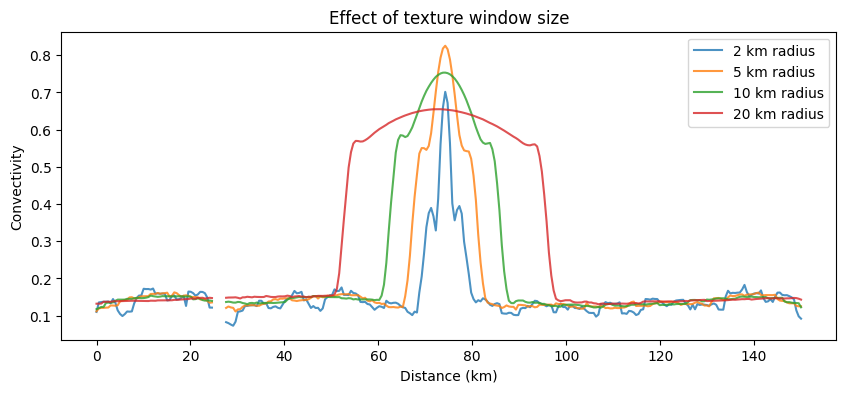

  2 km radius -> convective%=4.4
  5 km radius -> convective%=10.5
 10 km radius -> convective%=17.3
 20 km radius -> convective%=30.2


In [10]:
window_sizes_km = [2, 5, 10, 20]
fig, ax = plt.subplots(figsize=(10, 4))
for w_km in window_sizes_km:
    r = eccopy1d.run(dbz, coords=coords, window=WindowSpec((w_km, "km")))
    ax.plot(coords, r.convectivity, label=f"{w_km} km radius", alpha=0.8)
ax.set(xlabel="Distance (km)", ylabel="Convectivity", title="Effect of texture window size")
ax.legend()
plt.show()

for w_km in window_sizes_km:
    r = eccopy1d.run(dbz, coords=coords, window=WindowSpec((w_km, "km")))
    print(f"{w_km:>3} km radius -> convective%={stats.convective_percentage(r.echo_type):.1f}")

## Summary

- `WindowSpec` controls the texture window (physical or pixel; uniform
  or varying resolution).
- `TextureParams.upper_lim_dbz` controls how quickly texture saturates
  to convectivity=1.
- `ClassificationParams` sets the strat/mixed/conv thresholds and
  cleanup dilation radii.
- `return_intermediates=True` exposes the fitted/detrended fields that
  feed the texture statistic, for debugging.
- `eccopy.stats` computes coverage fractions and clump statistics
  generically from `echo_type`.
- `eccopy.core.colormaps` gives consistent, shared plotting colors
  across all four EccoPy modules.

See `eccopy2d_v_workflow.ipynb` next for a 2-D vertical cross-section,
including height/melt/temp sub-classification.
